# M2K SuperTrend flip, long-only, 15-minute bars (Tradovate exchange)

Same event-driven engine, cost model, and strategy
(`backtester.strategies.SuperTrendFlipStrategy`) as
`supertrend_flip_long_mes_15m.ipynb`, applied to **M2K** instead
of MES -- real OHLC resampled locally from Databento's full-history 1-minute
M2K continuous-contract Parquet file.

**Why this pass exists**: the MES long-only/15-minute version rescued
SuperTrend from a clearly negative result (5-minute bars, both directions) to
a promising one (TRAIN `trade_sharpe_lb` positive, TEST point estimate nearly
matching TRAIN). The same long-only Donchian breakout strategy transferred to
M2K at least as well as MES (MNQ notably *better*, M2K notably
weaker) -- this pass checks whether SuperTrend shows the same pattern.
`direction=long` from the outset, same length/multiplier grid as the MES
pass for direct comparability.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import StrategyDirection, SuperTrendFlipStrategy
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "M2K"
SYMBOL = "M2K/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/M2K_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 167703  span: 2019-05-05 22:14:59.999000 -> 2026-07-13 07:14:59.999000


## Grid search: SuperTrend length x ATR multiplier, direction=long

`risk_reward_ratio=None` (canonical: no fixed take-profit, exit on the next
flip or the hard stop, whichever comes first).


In [3]:
LENGTH_CANDIDATES = [7, 10, 20, 30, 50]
MULTIPLIER_CANDIDATES = [2.0, 3.0, 4.0]
DEPOSIT_USD = 50_000


def run_supertrend_backtest(ohlc_slice: pd.DataFrame, length: int, multiplier: float, key: str,
                             direction: StrategyDirection = StrategyDirection.long,
                             risk_reward_ratio: float | None = None):
    line, direction_series = Indicators.supertrend(ohlc_slice, length=length, multiplier=multiplier)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="line", df=line)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                          indicator_name="direction", df=direction_series)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=SuperTrendFlipStrategy(
            key=key, market=market, symbol=SYMBOL, line_key="line", direction_key="direction",
            risk_reward_ratio=risk_reward_ratio, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for length in LENGTH_CANDIDATES:
    for multiplier in MULTIPLIER_CANDIDATES:
        bt, drawdown_mw = run_supertrend_backtest(ohlc, length, multiplier, key=f"ST_long_{length}_{multiplier}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(length, multiplier)] = (bt, drawdown_mw)
        grid_rows.append({
            "length": length, "multiplier": multiplier,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(f"\ngrid done in {time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


length=7 done, 65s elapsed


length=10 done, 131s elapsed


length=20 done, 196s elapsed


length=30 done, 261s elapsed


length=50 done, 331s elapsed



grid done in 331s

    length  multiplier  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0       20         3.0           -5.126309      0.028952              -35.1824         2204.0            306.1         36.116152       1.104719               0.052579              1.050708           5.754118        15245.23           False
1       30         3.0          -13.613732     -0.039365              -37.3786         2211.0            307.1         36.363636       1.079504               0.032050              1.030846           3.262141        14019.46           False
2        7         4.0          -27.498120     -0.176280              -38.5571         1531.0            212.6         34.160679       1.029633              -0.004274              0.983286          -2.294827        10235.68           False
3       20         4

### Heatmaps: Sharpe ratio and net return across (length, multiplier)


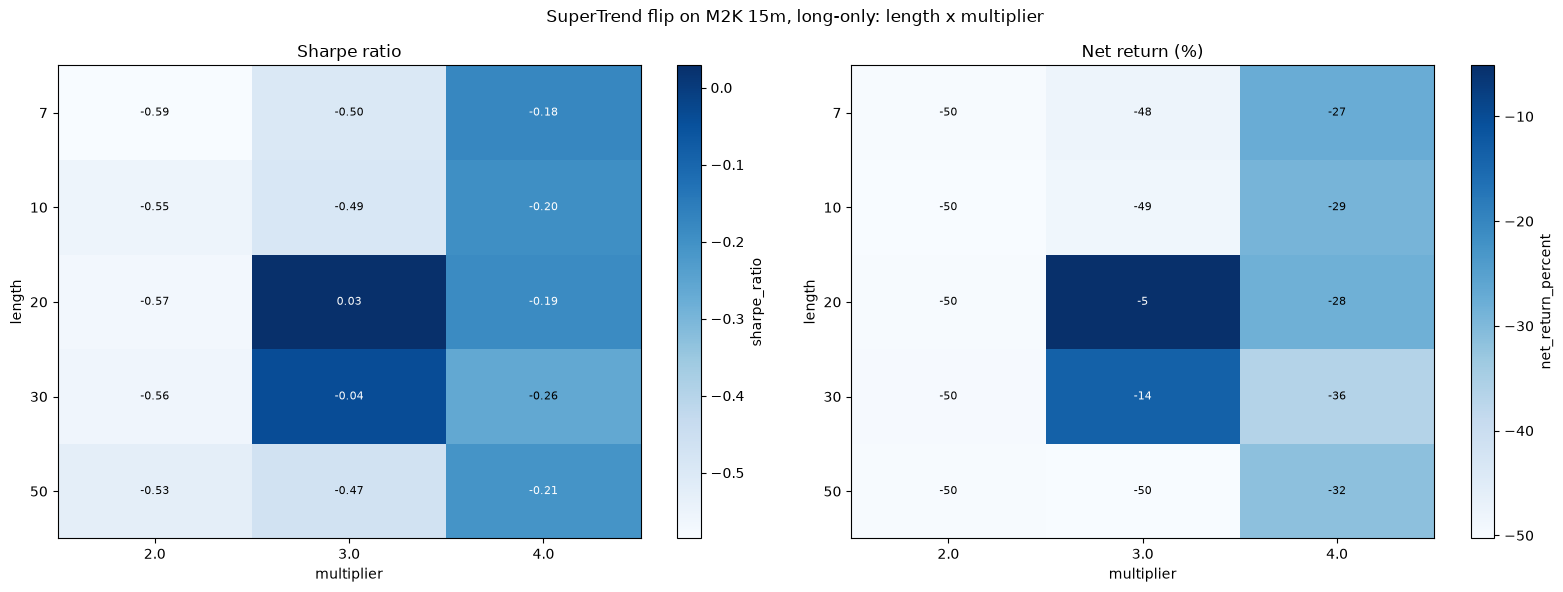

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("multiplier")
    ax.set_ylabel("length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="length", columns="multiplier", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="length", columns="multiplier", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"SuperTrend flip on {DISPLAY_SYMBOL} 15m, long-only: length x multiplier")
fig.tight_layout()
plt.show()


## Detailed report for the best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
grid's best combo -- same report format as every other notebook in this
pipeline.


Best combo: length=20, multiplier=3.0
Candles Processed: 167702
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,M2K/USD,description
sharpe_ratio,0.0290,-0.3953,-0.3796,0.5700,-0.7273,0.2989,0.6727,0.4431,0.7068,0.3891,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.0447,-0.6158,-0.5493,0.9146,-1.0947,0.5134,1.1738,0.7507,1.2585,0.5585,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,13.3783,8.4807,22.4243,11.2454,15.5439,9.8267,9.7752,10.4386,11.3593,21.7514,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-0.7288,-5.2309,-14.7960,8.7573,-16.6131,3.6343,9.2670,6.1135,11.3588,9.2282,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0207,-0.8079,-0.4352,0.9700,-0.8636,0.3436,1.5737,0.5551,1.9700,0.2116,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.1457,-0.5361,-0.4352,0.9672,-0.8615,0.3427,1.5737,0.5536,1.0152,2.0342,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-35.1824,-6.4750,-34.0015,-9.0285,-19.2361,-10.5759,-5.8887,-11.0127,-5.7660,-43.6096,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2497,111,316,144,363,166,135,199,57,1097,How long it took to recover the loss. Shorter is better.
ulcer_index,18.9128,2.9653,21.1173,3.2775,13.1861,4.6961,3.0689,4.3088,2.3037,15.6277,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-1.0779,-0.8475,-1.8331,-1.0558,-1.5401,-0.7593,-0.8444,-0.7633,-0.9619,-1.9930,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


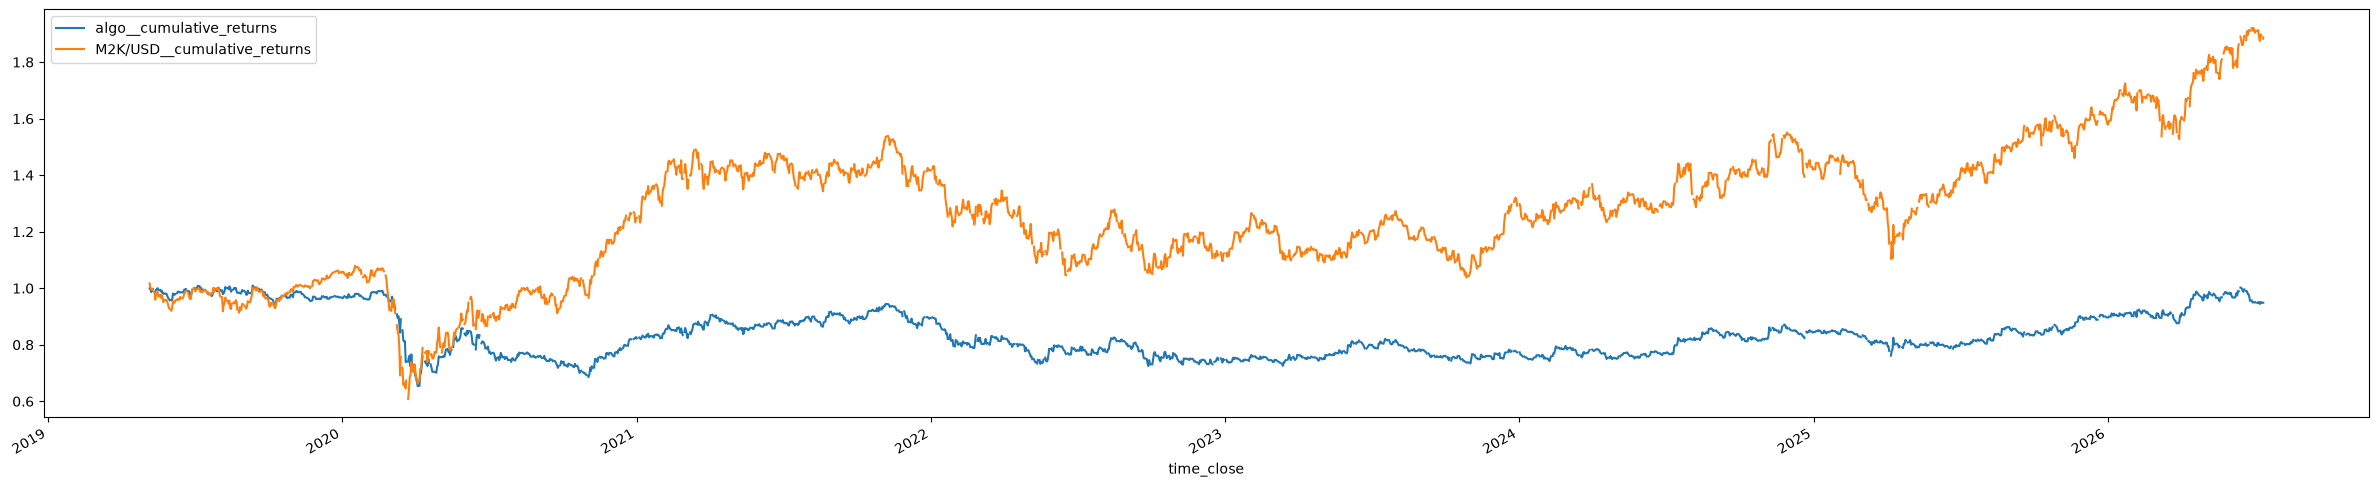

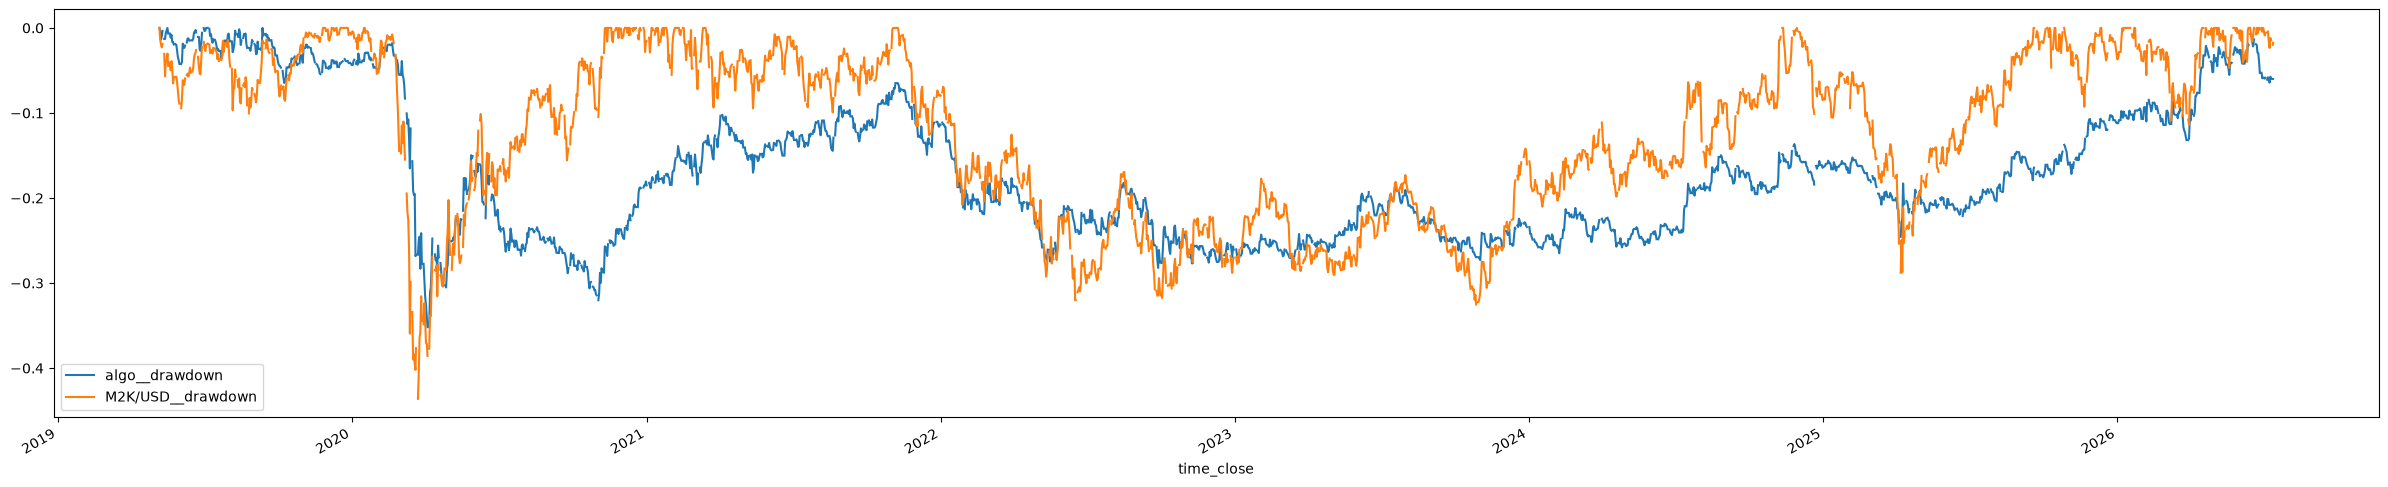

In [5]:
best_length, best_mult = grid_results.iloc[0][["length", "multiplier"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, multiplier={best_mult}")
best_backtest, best_drawdown_mw = grid_backtests[(best_length, best_mult)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: does the best combo survive a train/test split?


In [6]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_supertrend_backtest(ohlc_slice, best_length, float(best_mult), key=f"ST_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-25 15:59:59.999000  (125777 train bars, 41926 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       2204         36.116152      0.032268        -0.002781        0.028952           -5.126309              1.050708           5.754118              -35.1824           False
TRAIN (75%)                1651         35.372502      0.023520        -0.016970       -0.096017          -16.818114              1.019232           2.284799              -35.1824           False
TEST (last 25%, unseen)     552         38.224638      0.061736        -0.008347        0.564714           16.614283              1.174638          22.324224              -13.5318           False


## Findings

**Weak, same pattern as M2K's Donchian result.** Best combo by Sharpe
(`length=20, multiplier=3.0`): FULL Sharpe just 0.029 (barely above zero),
TRAIN `trade_sharpe_lb`=-0.017, TEST `trade_sharpe_lb`=-0.008 -- both negative,
though TEST's net return and `dollar_profit_factor` (+16.6%, 1.17) look
superficially decent on a small, noisy 552-trade sample. 3 of the top 10 grid
combos (the `multiplier=3.0` tightest-band cases at other lengths) breach the
drawdown middleware outright.

**Consistent with the Donchian finding on M2K**: neither of the two
structurally different trend-following strategies tested in this pipeline
finds a clean edge on M2K (Russell 2000 futures), while both find one on MNQ
and (more modestly) MES. This strengthens the working hypothesis that the
edge tracks how strongly directional the underlying index actually was over
2019-2026 -- small caps chopped and underperformed relative to the S&P and
especially the Nasdaq-100 mega-cap/AI-driven rally over this window. Not
worth walk-forward validating M2K further without a different approach (e.g.
a chop/regime filter, or accepting M2K doesn't carry this particular edge).
